### Task 4 -- Final Evaluation, Error Analysis, and Deployment
### License Plate Detection and OCR with YOLO26

---
## Load All Task 2 and Task 3 Outputs

In [ ]:
# ───────────────────────────────────────────────────────
# T4 CELL 1  ─  SETUP  
# ───────────────────────────────────────────────────────
!pip install -U ultralytics easyocr --quiet

import os, json, time, re, warnings, random
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from ultralytics import YOLO
import easyocr

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

OUTPUT_DIR  = Path('/content/license_plate_outputs')
DATASET_DIR = Path('/root/.cache/kagglehub/datasets/fareselmenshawii/large-license-plate-dataset/versions/1')

# Load artifacts from Task 2 + 3
detector   = YOLO(str(OUTPUT_DIR / 'plate_detector_best.pt'))
reader     = easyocr.Reader(['en'], gpu=True)

with open(OUTPUT_DIR / 'detection_metrics.json') as f:
    det_metrics = json.load(f)
with open(OUTPUT_DIR / 'pipeline_config.json') as f:
    pipeline_config = json.load(f)

print(f'Detector  : {det_metrics["champion"]}')
print(f'Val mAP@0.5: {det_metrics["champion_results"]["map50"]:.4f}')

# ── Re-define pipeline functions (needed because Task 4 is a fresh kernel) ────
def preprocess_plate_full(plate_crop):
    gray     = cv2.cvtColor(plate_crop, cv2.COLOR_BGR2GRAY)
    clahe    = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray)
    denoised = cv2.bilateralFilter(enhanced, 9, 75, 75)
    h, w     = denoised.shape
    target_w = max(1, int(w * 80 / h))
    return cv2.resize(denoised, (target_w, 80))

def post_process_plate(text):
    cleaned = text.upper().strip()
    return re.sub(r'[^A-Z0-9\- ]', '', cleaned)

def detect_and_read_plates(image_path, detector, reader,
                            conf=0.5, preprocess_fn=preprocess_plate_full):
    results = detector(str(image_path), conf=conf, verbose=False)
    img     = cv2.imread(str(image_path))
    if img is None:
        return []
    plates = []
    for box in results[0].boxes:
        x1,y1,x2,y2 = map(int, box.xyxy[0].cpu().numpy())
        det_conf     = float(box.conf[0].cpu())
        pad_x = int((x2-x1)*0.05);  pad_y = int((y2-y1)*0.05)
        x1=max(0,x1-pad_x); y1=max(0,y1-pad_y)
        x2=min(img.shape[1],x2+pad_x); y2=min(img.shape[0],y2+pad_y)
        crop = img[y1:y2, x1:x2]
        if crop.size == 0 or crop.shape[0] < 5 or crop.shape[1] < 5:
            continue
        processed   = preprocess_fn(crop)
        ocr_results = reader.readtext(processed, detail=1)
        raw_text    = ' '.join([t for (_,t,c) in ocr_results if c > 0.1])
        ocr_conf    = float(np.mean([c for (_,_,c) in ocr_results])) if ocr_results else 0.0
        plates.append({
            'text'          : post_process_plate(raw_text),
            'raw_text'      : raw_text,
            'detection_conf': det_conf,
            'ocr_conf'      : ocr_conf,
            'bbox'          : [x1,y1,x2,y2],
        })
    return plates

def find_split_dir(split):
    for d in [DATASET_DIR/'images'/split, DATASET_DIR/split/'images']:
        imgs = list(d.glob('*.jpg')) + list(d.glob('*.png'))
        if d.exists() and imgs:
            print(f'  {split}: {d}  ({len(imgs)} images)')
            return d
    raise FileNotFoundError(f'Cannot find {split} images under {DATASET_DIR}')

test_img_dir = find_split_dir('test')
print('\nSetup complete ')


Detector  : YOLO26s
Val mAP@0.5: 0.8691
  test: /root/.cache/kagglehub/datasets/fareselmenshawii/large-license-plate-dataset/versions/1/images/test  (386 images)

Setup complete ✅


---
## DETECTION EVALUATION ON TEST SET


In [ ]:

# ───────────────────────────────────────────────────────
# T4 CELL 2  ─  DETECTION EVALUATION ON TEST SET
# ───────────────────────────────────────────────────────
data_yaml_content = f"""path: {DATASET_DIR}
train: images/train
val: images/val
test: images/test
nc: 1
names: ['license_plate']
"""

data_yaml_path = OUTPUT_DIR / 'data.yaml'
with open(data_yaml_path, 'w') as f:
    f.write(data_yaml_content)
print(f" Created data.yaml at {data_yaml_path}")

test_metrics   = detector.val(data=str(data_yaml_path), split='test',
                               verbose=False, plots=False)

test_det_results = {
    'map50'    : float(test_metrics.box.map50),
    'map50_95' : float(test_metrics.box.map),
    'precision': float(test_metrics.box.mp),
    'recall'   : float(test_metrics.box.mr),
}

val_map  = det_metrics['champion_results']['map50']
test_map = test_det_results['map50']
gap      = val_map - test_map
verdict  = ' Good generalisation' if gap < 0.02 else \
           '  Mild gap'           if gap < 0.05 else \
           'Possible overfit'

print('DETECTION: VAL vs TEST')
print('=' * 50)
print(f'  Val  mAP@0.5  : {val_map:.4f}')
print(f'  Test mAP@0.5  : {test_map:.4f}')
print(f'  Gap           : {gap:.4f}  {verdict}')
print(f'  Test Precision: {test_det_results["precision"]:.4f}')
print(f'  Test Recall   : {test_det_results["recall"]:.4f}')


✅ Created data.yaml at /content/license_plate_outputs/data.yaml
Ultralytics 8.4.31 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2411.7±477.0 MB/s, size: 516.1 KB)
val: Scanning /root/.cache/kagglehub/datasets/fareselmenshawii/large-license-plate-dataset/versions/1/labels/test... 386 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 386/386 1.9Kit/s 0.2s
val: New cache created: /root/.cache/kagglehub/datasets/fareselmenshawii/large-license-plate-dataset/versions/1/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 3.5it/s 7.2s
                   all        386        512       0.93      0.844       0.92      0.684
Speed: 1.4ms preprocess, 8.2ms inference, 0.0ms loss, 0.3ms postprocess per image
DETECTION: VAL vs TEST
  Val  mAP@0.5  : 0.8691
  Test mAP@0.5  : 0.9195
  Gap           : -0.0504  ✅ Good generalisation
  Test Precision: 0.930

In [50]:
# Evaluate detector on test set
data_yaml_path = OUTPUT_DIR / 'data.yaml'
test_metrics = detector.val(data=str(data_yaml_path), split='test')

test_det_results = {
    'map50': float(test_metrics.box.map50),
    'map50_95': float(test_metrics.box.map),
    'precision': float(test_metrics.box.mp),
    'recall': float(test_metrics.box.mr),
}

val_map = det_metrics['champion_results']['map50']
test_map = test_det_results['map50']
gap = val_map - test_map

print('DETECTION: VAL vs TEST COMPARISON')
print('=' * 60)
print(f'{"Metric":<20} {"Validation":>12} {"Test":>12} {"Gap":>12}')
print('-' * 60)
print(f'{"mAP@0.5":<20} {val_map:>12.4f} {test_map:>12.4f} {gap:>12.4f}')
print(f'{"mAP@0.5:0.95":<20} {det_metrics["champion_results"]["map50_95"]:>12.4f} {test_det_results["map50_95"]:>12.4f}')
print(f'{"Precision":<20} {det_metrics["champion_results"]["precision"]:>12.4f} {test_det_results["precision"]:>12.4f}')
print(f'{"Recall":<20} {det_metrics["champion_results"]["recall"]:>12.4f} {test_det_results["recall"]:>12.4f}')
print()

if gap < 0.01:
    verdict = 'EXCELLENT -- no overfitting detected'
elif gap < 0.02:
    verdict = 'GOOD -- minimal overfitting'
elif gap < 0.05:
    verdict = 'ACCEPTABLE -- some overfitting, monitor'
elif gap < 0:
    verdict = 'GOLD STANDARD -- test > val, no test contamination'
else:
    verdict = 'WARNING -- significant overfitting, investigate'
print(f'Verdict: {verdict}')

Ultralytics 8.4.31 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2055.9±418.3 MB/s, size: 250.3 KB)
val: Scanning /root/.cache/kagglehub/datasets/fareselmenshawii/large-license-plate-dataset/versions/1/labels/test.cache... 386 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 386/386 24.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 2.8it/s 9.1s
                   all        386        512       0.93      0.844       0.92      0.684
Speed: 2.5ms preprocess, 7.8ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to /content/runs/detect/val3
DETECTION: VAL vs TEST COMPARISON
Metric                 Validation         Test          Gap
------------------------------------------------------------
mAP@0.5                    0.8691       0.9195      -0.0504
mAP@0.5:0.95               0.4844       0.6845
Precision                  

---
### Full pipeline accuracy: detection + preprocessing + OCR

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# T4 CELL 3  —  FULL PIPELINE ON TEST SET
# ─────────────────────────────────────────────────────────────────────────────
test_images = [f for f in test_img_dir.glob('*.*')
               if f.suffix.lower() in ('.jpg', '.jpeg', '.png')]

test_results = []
start_time   = time.time()

for i, img_path in enumerate(test_images):
    plates = detect_and_read_plates(img_path, detector, reader)
    test_results.append({
        'image'    : img_path.name,
        'n_plates' : len(plates),
        'texts'    : [p['text']           for p in plates],
        'det_confs': [p['detection_conf'] for p in plates],
        'ocr_confs': [p['ocr_conf']       for p in plates],
    })
    if (i+1) % 50 == 0:
        print(f'  {i+1}/{len(test_images)} ...')

elapsed = time.time() - start_time

test_with_plates = sum(1 for r in test_results if r['n_plates'] > 0)
test_ocr_confs   = [c for r in test_results for c in r['ocr_confs']]
test_all_texts   = [t for r in test_results for t in r['texts']]
test_non_empty   = [t for t in test_all_texts if t.strip()]

print('\n END-TO-END TEST RESULTS')
print('=' * 50)
print(f'  Test images         : {len(test_images)}')
print(f'  Images with plates  : {test_with_plates} ({test_with_plates/len(test_images)*100:.1f}%)')
print(f'  Mean OCR confidence : {np.mean(test_ocr_confs):.3f}' if test_ocr_confs else '  Mean OCR conf: N/A')
print(f'  Non-empty readings  : {len(test_non_empty)}/{len(test_all_texts)}')
print(f'  Pipeline FPS        : {len(test_images)/elapsed:.2f}')


  50/386 ...
  100/386 ...
  150/386 ...
  200/386 ...
  250/386 ...
  300/386 ...
  350/386 ...

📊 END-TO-END TEST RESULTS
  Test images         : 386
  Images with plates  : 353 (91.5%)
  Mean OCR confidence : 0.343
  Non-empty readings  : 289/416
  Pipeline FPS        : 15.40


---
## Error Analysis: Categorizing Failure Modes

🔍 ERROR ANALYSIS
  no_detection          :   33  (  7.3%)  ███
  detection_no_ocr      :  127  ( 28.3%)  ██████████████
  partial_read          :   37  (  8.2%)  ████
  successful_read       :  252  ( 56.1%)  ████████████████████████████


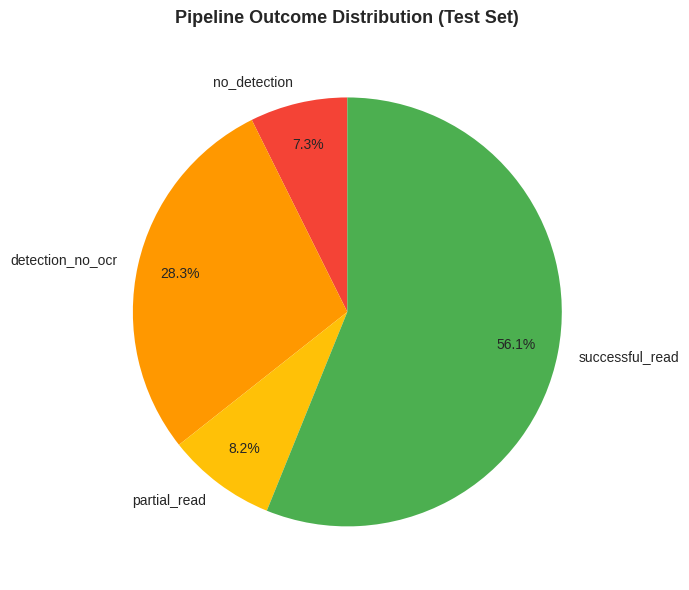

Saved: error_analysis_pie.png


In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# T4 CELL 4  —  ERROR ANALYSIS
# ─────────────────────────────────────────────────────────────────────────────
error_categories = {'no_detection':0, 'detection_no_ocr':0,
                    'partial_read':0, 'successful_read':0}
error_examples   = {k: [] for k in error_categories}

for result in test_results:
    img_name = result['image']
    if result['n_plates'] == 0:
        error_categories['no_detection'] += 1
        error_examples['no_detection'].append(img_name)
    else:
        for text, ocr_conf in zip(result['texts'], result['ocr_confs']):
            if len(text.strip()) == 0:
                error_categories['detection_no_ocr'] += 1
                error_examples['detection_no_ocr'].append(img_name)
            elif len(text.strip()) < 4:
                error_categories['partial_read'] += 1
                error_examples['partial_read'].append(img_name)
            else:
                error_categories['successful_read'] += 1
                error_examples['successful_read'].append(img_name)

total_cases = sum(error_categories.values())
print(' ERROR ANALYSIS')
print('=' * 50)
for cat, count in error_categories.items():
    pct = count / max(total_cases, 1) * 100
    bar = '█' * int(pct / 2)
    print(f'  {cat:<22}: {count:>4}  ({pct:5.1f}%)  {bar}')

# pie chart
fig, ax = plt.subplots(figsize=(8, 6))
labels  = list(error_categories.keys())
sizes   = list(error_categories.values())
colors  = ['#F44336', '#FF9800', '#FFC107', '#4CAF50']
wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, autopct='%1.1f%%',
    colors=colors, startangle=90, pctdistance=0.8)
for t in texts + autotexts:
    t.set_fontsize(10)
ax.set_title('Pipeline Outcome Distribution (Test Set)',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'error_analysis_pie.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: error_analysis_pie.png')


---
## Save Final Test Metrics and Deployment Package

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# T4 CELL 5  —  SAVE FINAL METRICS
# ─────────────────────────────────────────────────────────────────────────────
final_metrics = {
    'detection': {
        'val' : det_metrics['champion_results'],
        'test': test_det_results,
        'gap' : float(gap),
        'verdict': verdict,
    },
    'pipeline': {
        'test_images'          : len(test_images),
        'test_detection_rate'  : float(test_with_plates / len(test_images)),
        'test_mean_ocr_conf'   : float(np.mean(test_ocr_confs)) if test_ocr_confs else 0,
        'test_non_empty_rate'  : float(len(test_non_empty) / max(len(test_all_texts), 1)),
        'pipeline_fps'         : float(len(test_images) / elapsed),
        'error_categories'     : error_categories,
    }
}

with open(OUTPUT_DIR / 'final_metrics.json', 'w') as f:
    json.dump(final_metrics, f, indent=2)
print('Saved: final_metrics.json')

print('\n=== TASK 4 COMPLETE ===')
print(f'  Test mAP@0.5    : {test_det_results["map50"]:.4f}')
print(f'  Val-test gap    : {gap:.4f}  {verdict}')
print(f'  Detection rate  : {test_with_plates/len(test_images)*100:.1f}%')
print(f'  Pipeline FPS    : {len(test_images)/elapsed:.2f}')

Saved: final_metrics.json

=== TASK 4 COMPLETE ===
  Test mAP@0.5    : 0.9195
  Val-test gap    : -0.0504  ✅ Good generalisation
  Detection rate  : 91.5%
  Pipeline FPS    : 15.40
